In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("retail_sales_data.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
# ---------- Standardize column names ----------
df.columns = df.columns.str.lower().str.replace(" ", "_")

# ---------- Convert date column ----------
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# ---------- Remove duplicate transactions ----------
df = df.drop_duplicates()

# ---------- Handle missing values (SAFE method) ----------
df["age"] = df["age"].fillna(df["age"].median())
df["gender"] = df["gender"].fillna("Unknown")
df["product_category"] = df["product_category"].fillna("Unknown")
df["quantity"] = df["quantity"].fillna(0)
df["price_per_unit"] = df["price_per_unit"].fillna(df["price_per_unit"].median())
df["total_amount"] = df["total_amount"].fillna(
    df["quantity"] * df["price_per_unit"]
)

# ---------- Feature Engineering ----------
# Date features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day_name()
df["quarter"] = df["date"].dt.quarter

# Age Groups (as per project guideline)
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 17, 25, 35, 45, 55, 65, 120],
    labels=["<18", "18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
)

df.head()

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,year,month,day,quarter,age_group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11,Friday,4,26-35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2,Monday,1,26-35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1,Friday,1,46-55
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5,Sunday,2,36-45
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5,Saturday,2,26-35


In [4]:
df.groupby("product_category")["total_amount"].sum().sort_values(ascending=False)

,total_amount
product_category,
Electronics,156905
Clothing,155580
Beauty,143515


<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='month'>

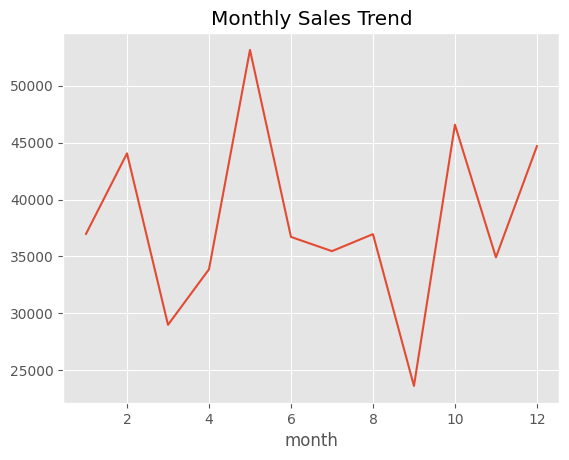

In [5]:
df.groupby("month")["total_amount"].sum().plot(kind="line", title="Monthly Sales Trend")

In [6]:
# ---------- Select features and target ----------
X = df[["quantity", "price_per_unit", "age", "month"]]
y = df["total_amount"]

# ---------- Train-test split ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------- Train Random Forest model ----------
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

# ---------- Predictions ----------
pred = model.predict(X_test)

# ---------- Evaluation ----------
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("Model Evaluation Metrics")
print("------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

Model Evaluation Metrics
------------------------
MAE : 0.0
RMSE: 0.0
R2  : 1.0


In [7]:
cust = df.groupby("customer_id").agg({
    "total_amount":"sum",
    "quantity":"sum"
})

kmeans = KMeans(n_clusters=4, random_state=42)
cust["segment"] = kmeans.fit_predict(cust)

cust.head()

,total_amount,quantity,segment
customer_id,,,
CUST001,150,3,0
CUST002,1000,2,1
CUST003,30,1,0
CUST004,500,1,3
CUST005,100,2,0


In [8]:
# Save cleaned sales data for Visulization
df.to_csv("clean_sales.csv", index=False)

# Save customer segmentation table for Visulization
cust.to_csv("customer_segments.csv", index=True)